# Customer Segmentation

# Problem Understanding
* We are launching a new business line. One problem we are facing is: What market should we target at? 
* Perhaps, instead of, targeting at one market only, we should develop a series of products and sell them to different groups of customers. 
* From our database, we extract customer data, which include customer's age, yearly income and spending amount.
* Is it possible to use the data to segment customers? 

In [1]:
# -- import the libraries --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn import metrics

In [2]:
# -- load the dataset --

customer=pd.read_csv('https://raw.githubusercontent.com/ttchuang/dataset/master/Mall_Customers.csv')
customer.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Undertand the Dataset

In [3]:
# -- Properties of the dataset --
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# -- Rename column names  --
customer.rename(columns={'Annual Income (k$)':'Annual_Income','Spending Score (1-100)':'Spending'},
               inplace=True)
customer.head()

,CustomerID,Gender,Age,Annual_Income,Spending
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# -- preview the dataset --
X = customer[['Annual_Income','Spending']].copy()
X.head()

,Annual_Income,Spending
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Standardize the dataset
* Note: It is not strictly necessary to standardize the data to cluster

In [6]:
# -- standardize the data --
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X[['Annual_Income','Spending']])


StandardScaler()

In [7]:
# -- standardize the data --
X[['Annual_Income_z','Spending_z']] = scaler.transform(X[['Annual_Income','Spending']])
    
X.head()

,Annual_Income,Spending,Annual_Income_z,Spending_z
0,15,39,-1.738999,-0.434801
1,15,81,-1.738999,1.195704
2,16,6,-1.700830,-1.715913
3,16,77,-1.700830,1.040418
4,17,40,-1.662660,-0.395980


# KMeans - Clustering

In [8]:
# -- fit the model with data --
kmeans_customer = KMeans(n_clusters = 5, n_init='auto')
kmeans_customer.fit(X[['Annual_Income_z','Spending_z']])

KMeans(n_clusters=5)

In [9]:
# -- Save the labels --
cluster = kmeans_customer.labels_
len(cluster)

200

In [10]:
# -- Obtain the labels --
cluster = kmeans_customer.labels_
cluster

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 1,
       0, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 4, 2, 1, 2, 4, 2, 4, 2,
       1, 2, 4, 2, 4, 2, 4, 2, 4, 2, 1, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2], dtype=int32)

In [11]:
# -- obtain the centroids --
cluster_center = kmeans_customer.cluster_centers_
cluster_center

array([[-1.30751869, -1.13696536],
       [-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907]])

In [12]:
# -- Merge data to create clusters --
customer_cluster = pd.concat([X,pd.DataFrame(cluster, columns=['cluster'])],
                             axis=1)
customer_cluster.head()

,Annual_Income,Spending,Annual_Income_z,Spending_z,cluster
0,15,39,-1.738999,-0.434801,0
1,15,81,-1.738999,1.195704,3
2,16,6,-1.700830,-1.715913,0
3,16,77,-1.700830,1.040418,3
4,17,40,-1.662660,-0.395980,0


# Plot the clusters

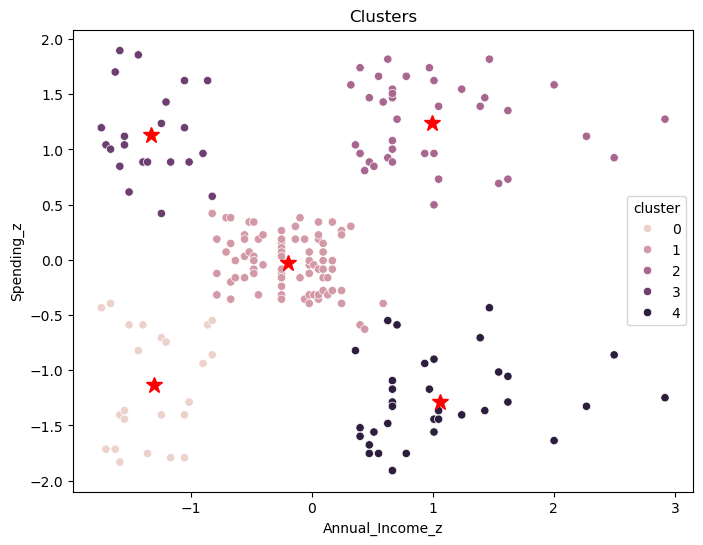

In [13]:
# -- plot clusters --
plt.figure(figsize=(8,6))

sns.scatterplot(x='Annual_Income_z',
                y='Spending_z',
                hue = 'cluster',
                data=customer_cluster,
                legend='full')

plt.plot(cluster_center[:,0],
         cluster_center[:,1],
         'r*',
        ms=12)
plt.title('Clusters');

# How to determine an optimal k? 


## The Elbow Method


In [14]:
# --- Calculate Within-Cluster-Sum of Squared ---
inertia = []
df = customer_cluster[['Annual_Income_z','Spending_z']]
K = range(1,10)
for k in K:
    kmeans = KMeans(n_clusters=k,n_init='auto')
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

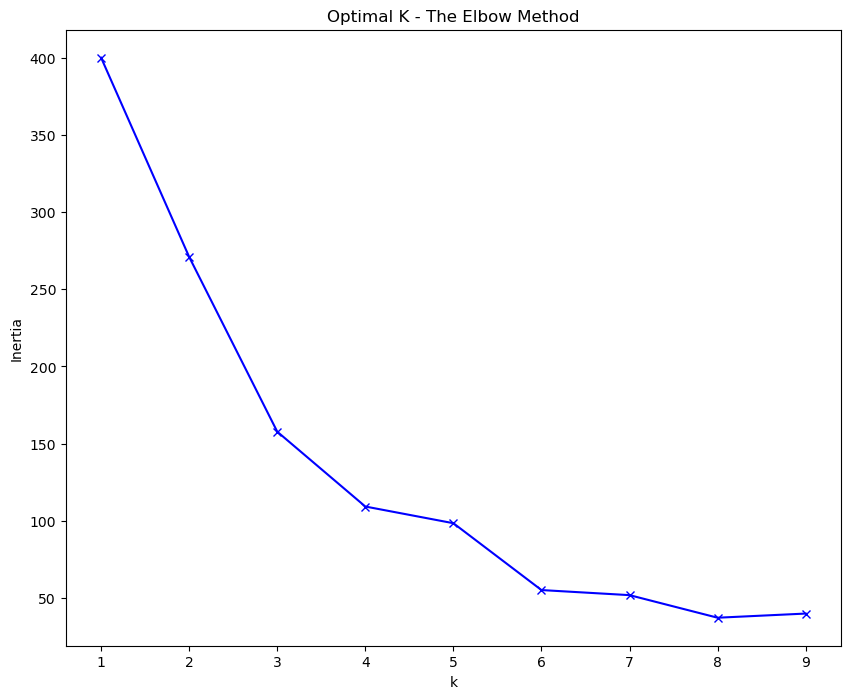

In [15]:
plt.figure(figsize=(10,8))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Optimal K - The Elbow Method')
plt.show()

## Elbow Method Function

In [16]:
# -- Define a elbow function --
def elbow(min_k,max_k,X):
    inertia = []
    K = range(min_k,max_k)
    for k in K:
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(10,8))
    plt.plot(K, inertia,
             'bx-')
    plt.xlabel('k')
    plt.ylabel('Inertia')
    plt.title('Optimal K - The Elbow Method')
    plt.grid(True)
    plt.show();        

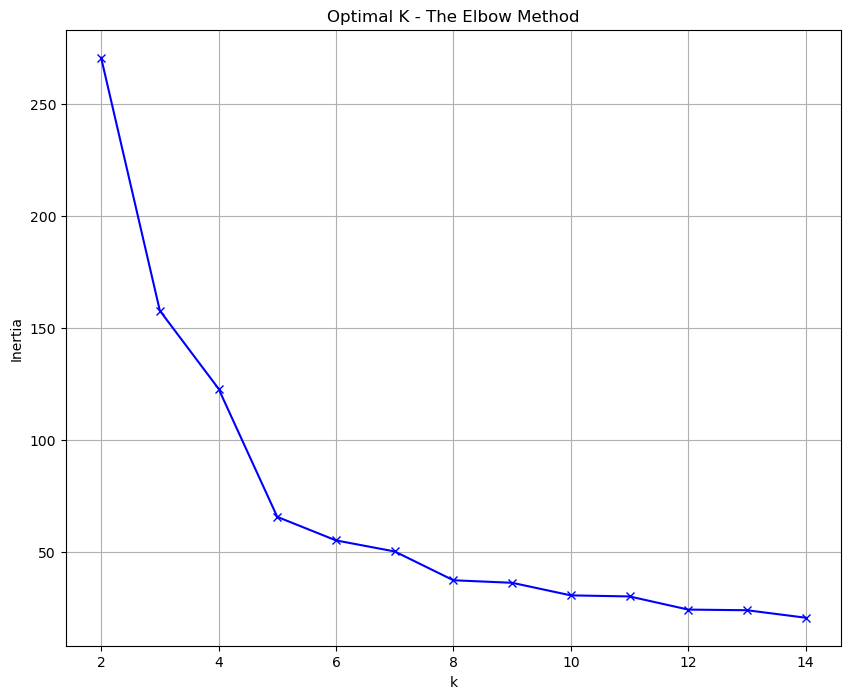

In [17]:
# -- Run the Elbow function --
min_k = 2
max_k = 15
elbow(min_k,max_k,df)

## Silhouette Coefficient

Silhouette Coefficient for k =  2  is  0.3774946694950023
Silhouette Coefficient for k =  3  is  0.46761208429590906
Silhouette Coefficient for k =  4  is  0.49379541737462135
Silhouette Coefficient for k =  5  is  0.5539331351051188
Silhouette Coefficient for k =  6  is  0.5367559826413595
Silhouette Coefficient for k =  7  is  0.4909506941993975
Silhouette Coefficient for k =  8  is  0.44297873404533006
Silhouette Coefficient for k =  9  is  0.45954757028800886
Silhouette Coefficient for k =  10  is  0.4058869043932535
Silhouette Coefficient for k =  11  is  0.4148372082159612
Silhouette Coefficient for k =  12  is  0.4308421403657888
Silhouette Coefficient for k =  13  is  0.4021928362573181
Silhouette Coefficient for k =  14  is  0.4141519776338704
Optimal K is  5


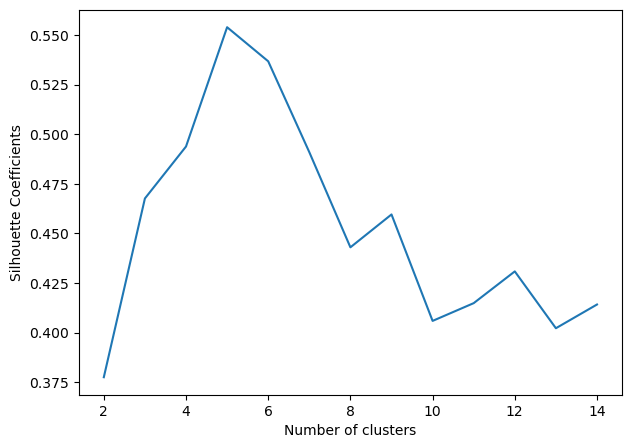

In [18]:
# --- Find Optimal K ---
silhouette_avgs = []
min_k = 2
max_k = 15

# --- try k from 2 to maximum number of labels ---
for k in range(min_k, max_k):
    kmean = KMeans(n_clusters = k,n_init='auto').fit(X)
    score = metrics.silhouette_score(X, kmean.labels_)
    print('Silhouette Coefficient for k = ',k,' is ', score)
    silhouette_avgs.append(score)
    
f, ax = plt.subplots(figsize=(7,5))
ax.plot(range(min_k, max_k),silhouette_avgs)

plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficients')

# --- the optimal k is the one with the highet average silhouette ---
Optimal_K = silhouette_avgs.index(max(silhouette_avgs)) + min_k
print('Optimal K is ', Optimal_K)


## Silhouette Coefficient Function

In [19]:
# --- Define a Silhouette Function ---
def silhouette(min_k,max_k, X):
    silhouette_avgs = []

    # --- try k from 2 to maximum number of labels ---
    for k in range(min_k, max_k):
        kmean = KMeans(n_clusters = k,n_init='auto').fit(X)
        score = metrics.silhouette_score(X, kmean.labels_)
        print('Silhouette Coefficient for k = ',k,' is ', score)
        silhouette_avgs.append(score)

    # --- the optimal k is the one with the highet average silhouette ---
    Optimal_K = silhouette_avgs.index(max(silhouette_avgs)) + min_k
    print('Optimal K is ', Optimal_K)
    
    f, ax = plt.subplots(figsize=(7,5))
    ax.plot(range(min_k, max_k),silhouette_avgs)
    
    plt.title('Silhouette Coefficient')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette Coefficients')
    plt.grid(True)
    plt.show()

Silhouette Coefficient for k =  2  is  0.38874761742430947
Silhouette Coefficient for k =  3  is  0.46658474419000145
Silhouette Coefficient for k =  4  is  0.4939069237513199
Silhouette Coefficient for k =  5  is  0.5546571631111091
Silhouette Coefficient for k =  6  is  0.5377141165734254
Silhouette Coefficient for k =  7  is  0.473403803861123
Silhouette Coefficient for k =  8  is  0.4454847343927295
Silhouette Coefficient for k =  9  is  0.44743372673372744
Silhouette Coefficient for k =  10  is  0.4167326617706131
Silhouette Coefficient for k =  11  is  0.42630413485412844
Silhouette Coefficient for k =  12  is  0.42938996565836623
Silhouette Coefficient for k =  13  is  0.3955376809259701
Silhouette Coefficient for k =  14  is  0.4294638606731898
Optimal K is  5


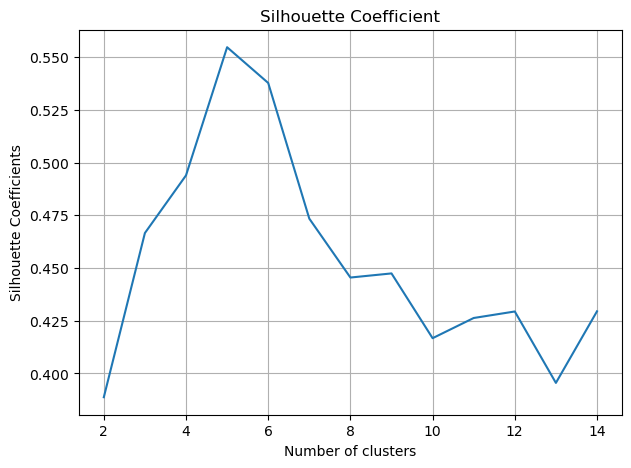

In [20]:
# -- Use the silhouette function to find optimal K --
silhouette(2,15,df)

## Davies–Bouldin Index (DBI)
* DBI measures how similar each cluster is to its most similar neighboring cluster. It is concerned with the cluster overlap. It is the average of the maximum ratio of cluster similarity (within-cluster dispersion to between-cluster separation) for each cluster.  
* Interpretation: Lower DBI = better clustering 
* It penalizes: 
    * large spread within clusters 
    * small distance between clusters 
* DBI focuses on the worst-case overlap between clusters
* Limitations
    * Sensitive to noise and outliers 
    * Assumes clusters are roughly spherical


In [21]:
# --- Define a Davies-Bouldin Index Function ---
def dbi(min_k,max_k, X):
    dbi_avgs = []

    # --- try k from 2 to maximum number of labels ---
    for k in range(min_k, max_k):
        kmean = KMeans(n_clusters = k,n_init='auto').fit(X)
        score = metrics.davies_bouldin_score(X, kmean.labels_)
        print('Davies-Bouldin Index for k = ',k,' is ', score)
        dbi_avgs.append(score)

    # --- the optimal k is the one with the highet average silhouette ---
    Optimal_K = dbi_avgs.index(min(dbi_avgs)) + min_k
    print('Optimal K is ', Optimal_K)
    
    f, ax = plt.subplots(figsize=(7,5))
    ax.plot(range(min_k, max_k),dbi_avgs)
    
    plt.title('Davies-Bouldin Index')
    plt.xlabel('Number of clusters')
    plt.ylabel('DBI')
    plt.grid(True)
    plt.show()

Davies-Bouldin Index for k =  2  is  1.2682841069011208
Davies-Bouldin Index for k =  3  is  0.7164821569435492
Davies-Bouldin Index for k =  4  is  0.6974596547758415
Davies-Bouldin Index for k =  5  is  0.5722356162263352
Davies-Bouldin Index for k =  6  is  0.8123736279725081
Davies-Bouldin Index for k =  7  is  0.7087379165160048
Davies-Bouldin Index for k =  8  is  0.8367231090773068
Davies-Bouldin Index for k =  9  is  0.7462222123929947
Davies-Bouldin Index for k =  10  is  0.8005922715674585
Davies-Bouldin Index for k =  11  is  0.8617419955448689
Davies-Bouldin Index for k =  12  is  0.81436424643177
Davies-Bouldin Index for k =  13  is  0.7864477799210079
Davies-Bouldin Index for k =  14  is  0.7464396371066826
Optimal K is  5


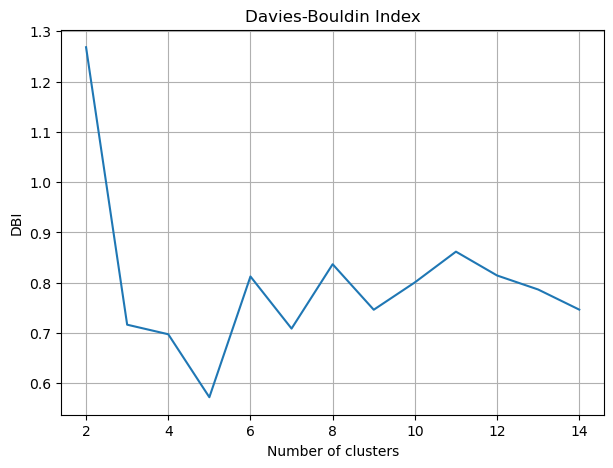

In [22]:
# -- Use the silhouette function to find optimal K --
dbi(2,15,df)

## Calinski–Harabasz Index (CHI)

* CHI measures how well clusters explain the variance in the data. It is inspired by ANOVA (analysis of variance)

* Interpretation: Higher CHI = better clustering 
* Good clustering: 
    * large between-cluster variance 
    * small within-cluster variance 
* CH measures how much of the data structure is explained by clustering
* Limitations
    * Prefers well-separated, spherical clusters 
    * May increase with larger K (overfitting risk) 

In [23]:
# --- Define a Calinski_Harabasz Index Function ---
def chi(min_k,max_k, X):
    chi_avgs = []

    # --- try k from 2 to maximum number of labels ---
    for k in range(min_k, max_k):
        kmean = KMeans(n_clusters = k,n_init='auto').fit(X)
        score = metrics.calinski_harabasz_score(X, kmean.labels_)
        print('Calinski-Harabasz Index for k = ',k,' is ', score)
        chi_avgs.append(score)

    # --- the optimal k is the one with the highet average silhouette ---
    Optimal_K = chi_avgs.index(max(chi_avgs)) + min_k
    print('Optimal K is ', Optimal_K)
    
    f, ax = plt.subplots(figsize=(7,5))
    ax.plot(range(min_k, max_k),chi_avgs)
    
    plt.title('Calinski-Harabasz Index')
    plt.xlabel('Number of clusters')
    plt.ylabel('CHI')
    plt.grid(True)
    plt.show()

Calinski-Harabasz Index for k =  2  is  91.40081927586573
Calinski-Harabasz Index for k =  3  is  151.33512126359477
Calinski-Harabasz Index for k =  4  is  123.25882993928774
Calinski-Harabasz Index for k =  5  is  248.64932001536357
Calinski-Harabasz Index for k =  6  is  242.79698851790556
Calinski-Harabasz Index for k =  7  is  242.07581396001314
Calinski-Harabasz Index for k =  8  is  219.4520040274044
Calinski-Harabasz Index for k =  9  is  208.3133764152213
Calinski-Harabasz Index for k =  10  is  268.7712738444024
Calinski-Harabasz Index for k =  11  is  230.64947194475474
Calinski-Harabasz Index for k =  12  is  258.646755733154
Calinski-Harabasz Index for k =  13  is  259.0021942487996
Calinski-Harabasz Index for k =  14  is  275.13358755795747
Optimal K is  14


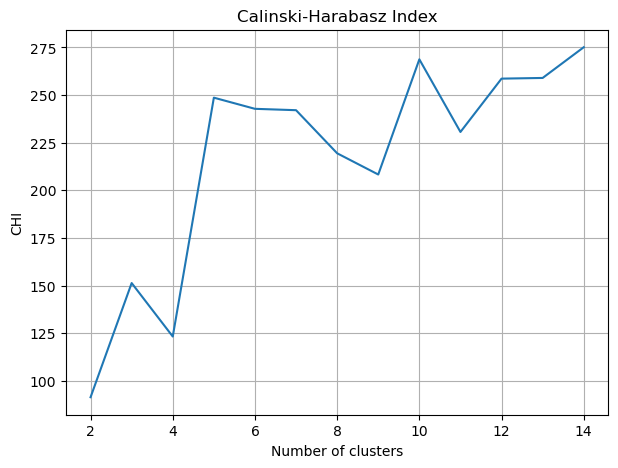

In [24]:
# -- Use the silhouette function to find optimal K --
chi(2,15,df)